##Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import zipfile
import os
import cv2

##Extract Dataset

In [2]:
zip_path = "brain_tumor_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()

##Check Dataset

In [3]:
print(os.listdir())
print(os.listdir("brain_tumor_dataset"))

['.config', 'yes', '.ipynb_checkpoints', 'no', 'brain_tumor_dataset', 'brain_tumor_dataset.zip', 'sample_data']
['yes', 'no']


##Dataset Loader

In [4]:
dataset_path = "brain_tumor_dataset"

img_size = (128,128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation"
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


##CNN Model

In [5]:
model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##Compile Model

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##Train Model

In [7]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6552 - loss: 0.7563 - val_accuracy: 0.7600 - val_loss: 0.6148
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 819ms/step - accuracy: 0.7586 - loss: 0.5731 - val_accuracy: 0.7400 - val_loss: 0.6156
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7537 - loss: 0.5203 - val_accuracy: 0.7600 - val_loss: 0.6696
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 829ms/step - accuracy: 0.7833 - loss: 0.5444 - val_accuracy: 0.7400 - val_loss: 0.5524
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8030 - loss: 0.5115 - val_accuracy: 0.7400 - val_loss: 0.5536
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 906ms/step - accuracy: 0.8128 - loss: 0.4642 - val_accuracy: 0.7600 - val_loss: 0.5772
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8177 - loss: 0.4338 - val_accuracy: 0.7400 - val_loss: 0.5326
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 816ms/step - accuracy: 0.8571 - loss: 0.3842 - val_accuracy: 0.7600 - val_loss: 0.5736
Epoc

In [8]:
last_conv_layer = model.layers[4]

cam_model = tf.keras.Model(
    inputs=model.layers[0].input,
    outputs=[last_conv_layer.output, model.layers[-1].output]
)

##Accuracy Plot

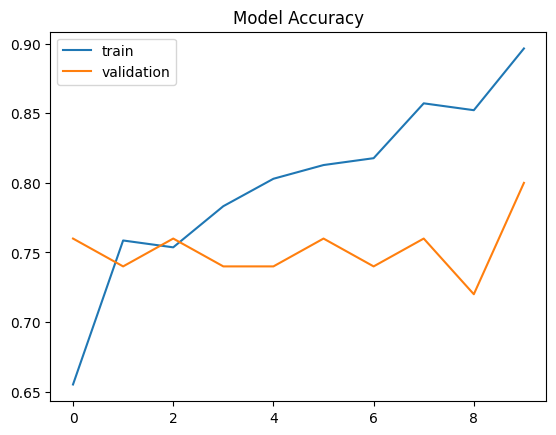

In [9]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(["train","validation"])
plt.title("Model Accuracy")
plt.show()

#Extract Filters

In [10]:
filters, biases = model.layers[0].get_weights()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

##Display Filters

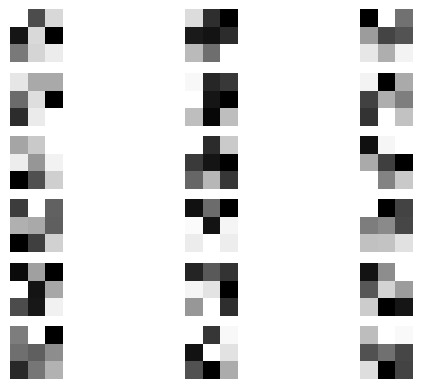

In [11]:
for i in range(6):

    f = filters[:,:,:,i]

    for j in range(3):
        ax = plt.subplot(6,3,i*3+j+1)
        plt.imshow(f[:,:,j], cmap='gray')
        plt.axis('off')

plt.show()

##Select Test Image

In [12]:
img_path = "brain_tumor_dataset/yes/Y1.jpg"

##Load Image

In [13]:
img = keras.preprocessing.image.load_img(img_path,target_size=(128,128))
img_array = keras.preprocessing.image.img_to_array(img)/255
img_array = np.expand_dims(img_array,axis=0)

##Prediction

In [14]:
pred = model.predict(img_array)

print("Tumor Probability:", pred[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Tumor Probability: 0.94328105
